In [34]:
# Importar la librería pandas
import pandas as pd

# Cargar el archivo desde la ruta local
df = pd.read_csv(r'C:\Users\LENOVO\Documents\Tarea 4\k-means.csv')

# Mostrar las primeras 5 filas
df.head()


import os
os.environ["OMP_NUM_THREADS"] = "1"



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ver la estructura general del dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Describir estadísticamente las columnas numéricas
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# Verificar si hay valores nulos
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

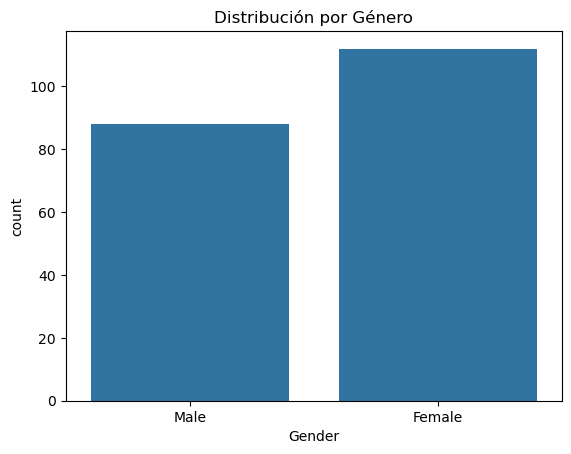

In [10]:
# Conteo de género
sns.countplot(x='Gender', data=df)
plt.title('Distribución por Género')
plt.show()

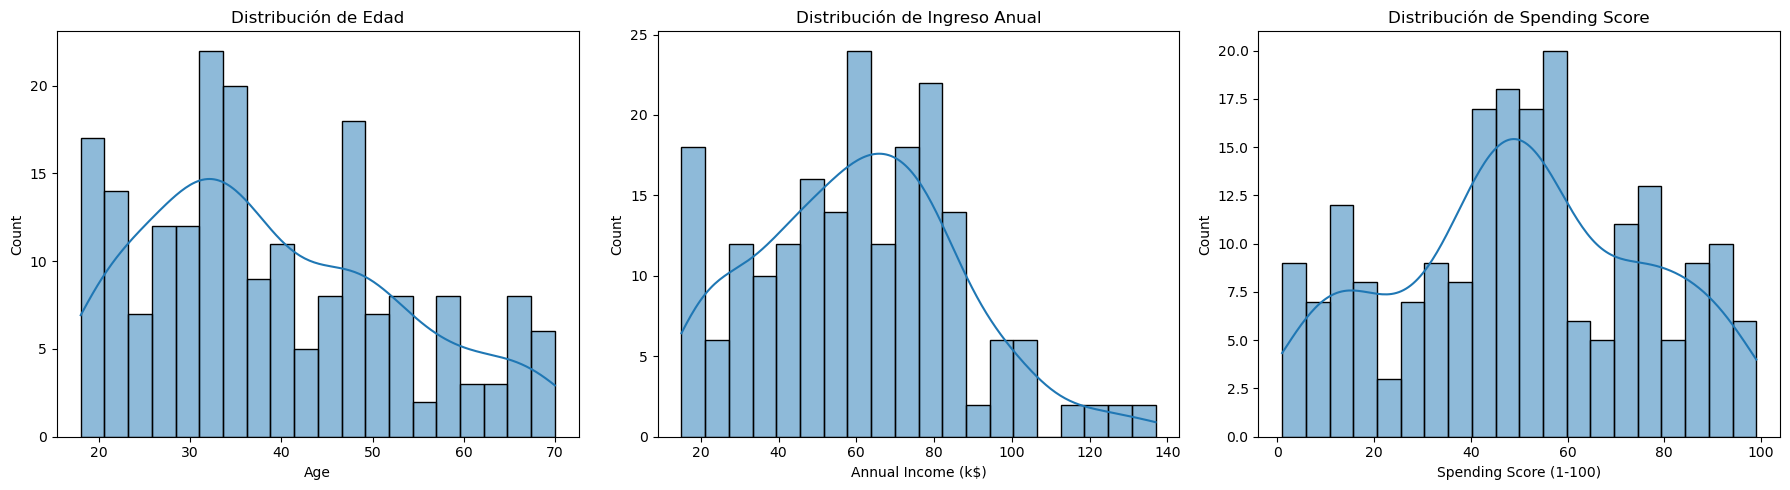

In [12]:
# Histogramas para Age, Income y Spending Score
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, bins=20, ax=axs[0])
axs[0].set_title('Distribución de Edad')

sns.histplot(df['Annual Income (k$)'], kde=True, bins=20, ax=axs[1])
axs[1].set_title('Distribución de Ingreso Anual')

sns.histplot(df['Spending Score (1-100)'], kde=True, bins=20, ax=axs[2])
axs[2].set_title('Distribución de Spending Score')

plt.tight_layout()
plt.show()

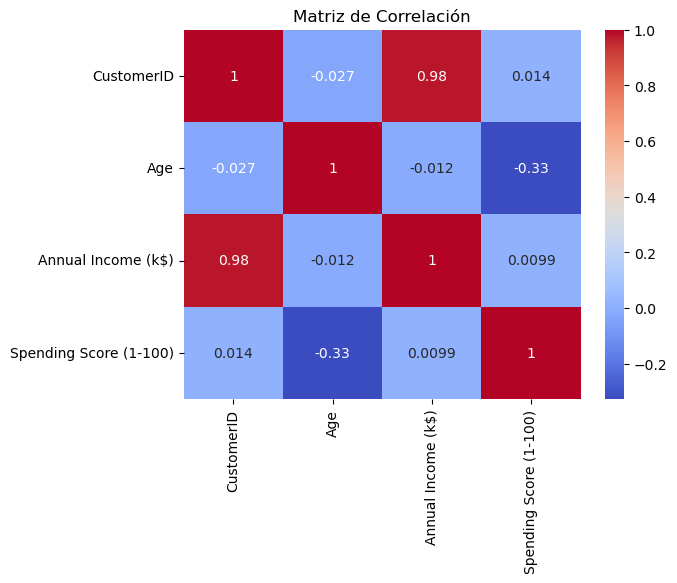

In [14]:
# Matriz de correlación entre variables numéricas
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [16]:
# Eliminar columna CustomerID, ya que no aporta a la segmentación
df_processed = df.drop('CustomerID', axis=1)


In [18]:
# Convertir la columna 'Gender' en variable numérica (0 = Female, 1 = Male)
df_processed['Gender'] = df_processed['Gender'].map({'Female': 0, 'Male': 1})

In [20]:
# Confirmar que los cambios se realizaron correctamente
df_processed.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [22]:
# Escalar los datos con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_processed)

# Convertir de nuevo a DataFrame para facilitar el análisis posterior
import pandas as pd
df_scaled = pd.DataFrame(scaled_data, columns=df_processed.columns)

# Mostrar los primeros registros escalados
df_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

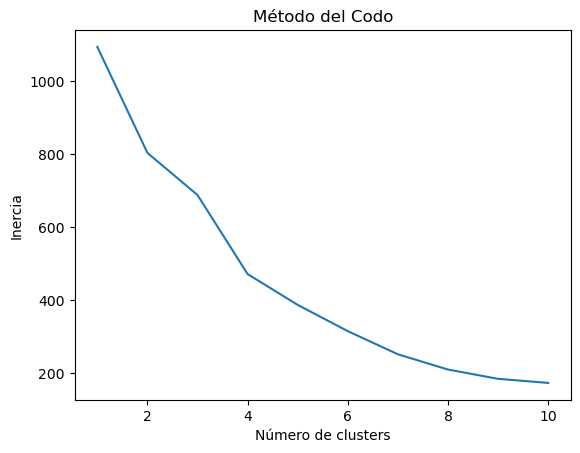

In [40]:
# Importamos las librerías necesarias
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Método del codo para encontrar el mejor número de clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)  # Asumiendo que 'df_scaled' es tu DataFrame preprocesado
    inertia.append(kmeans.inertia_)

# Gráfico para ver el método del codo
plt.plot(range(1, 11), inertia)
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

In [42]:
# Entrenar K-means con 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(df_scaled)

# Asignar las etiquetas de los clusters al DataFrame
df_scaled['Cluster'] = kmeans.labels_

# Mostrar los primeros registros con sus etiquetas de cluster
df_scaled.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1.128152,-1.424569,-1.738999,-0.434801,3
1,1.128152,-1.281035,-1.738999,1.195704,3
2,-0.886405,-1.352802,-1.700830,-1.715913,2
3,-0.886405,-1.137502,-1.700830,1.040418,1
4,-0.886405,-0.563369,-1.662660,-0.395980,1


In [44]:
from sklearn.metrics import silhouette_score

# Calcular el coeficiente de Silhouette
silhouette_avg = silhouette_score(df_scaled.drop('Cluster', axis=1), df_scaled['Cluster'])
print(f'Coeficiente de Silhouette: {silhouette_avg}')

Coeficiente de Silhouette: 0.31772048144221043


In [46]:
from sklearn.metrics import calinski_harabasz_score

# Calcular el índice de Calinski-Harabasz
calinski_score = calinski_harabasz_score(df_scaled.drop('Cluster', axis=1), df_scaled['Cluster'])
print(f'Índice de Calinski-Harabasz: {calinski_score}')

Índice de Calinski-Harabasz: 68.60641067741747


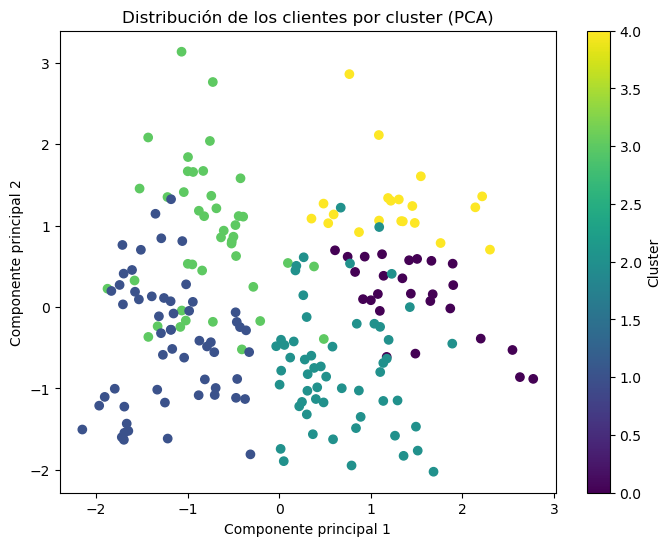

In [48]:
from sklearn.decomposition import PCA

# Reducir la dimensionalidad a 2D usando PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled.drop('Cluster', axis=1))

# Crear un gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=df_scaled['Cluster'], cmap='viridis')
plt.title('Distribución de los clientes por cluster (PCA)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.colorbar(label='Cluster')
plt.show()

In [52]:
from sklearn.cluster import AgglomerativeClustering

# Entrenar el modelo de clustering jerárquico
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='ward')
df_scaled['Cluster_Hierarchical'] = hierarchical.fit_predict(df_scaled.drop('Cluster', axis=1))

# Mostrar los primeros registros con los clusters asignados
df_scaled.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_Hierarchical
0,1.128152,-1.424569,-1.738999,-0.434801,3,0
1,1.128152,-1.281035,-1.738999,1.195704,3,0
2,-0.886405,-1.352802,-1.700830,-1.715913,2,3
3,-0.886405,-1.137502,-1.700830,1.040418,1,0
4,-0.886405,-0.563369,-1.662660,-0.395980,1,3


In [54]:
# Calcular el coeficiente de Silhouette para el modelo jerárquico
silhouette_avg_hierarchical = silhouette_score(df_scaled.drop('Cluster', axis=1), df_scaled['Cluster_Hierarchical'])
print(f'Coeficiente de Silhouette para el clustering jerárquico: {silhouette_avg_hierarchical}')

Coeficiente de Silhouette para el clustering jerárquico: 0.391279298417534


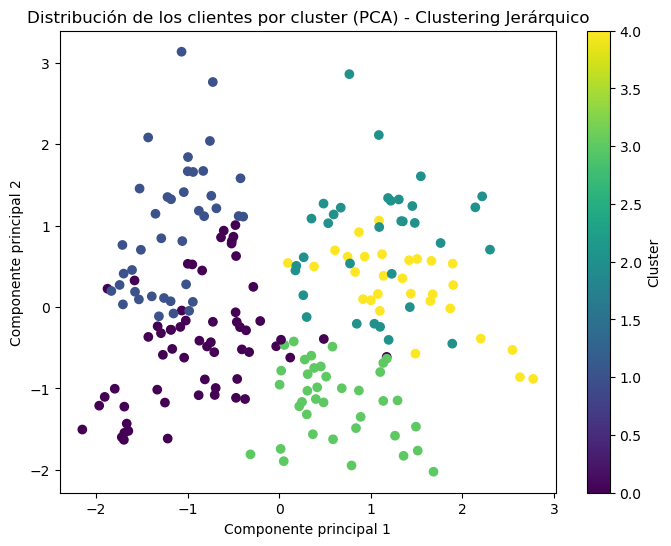

In [56]:
# Reducir la dimensionalidad a 2D usando PCA
pca_components_hierarchical = pca.fit_transform(df_scaled.drop(['Cluster', 'Cluster_Hierarchical'], axis=1))

# Crear un gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(pca_components_hierarchical[:, 0], pca_components_hierarchical[:, 1], c=df_scaled['Cluster_Hierarchical'], cmap='viridis')
plt.title('Distribución de los clientes por cluster (PCA) - Clustering Jerárquico')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.colorbar(label='Cluster')
plt.show()